In [1]:
# ============================================================
# PHASE 4 — EDA SETUP
# Load data, define theme, and prepare chart export system
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path


# ============================================================
# Create folders for chart exports
# ============================================================

Path("../images").mkdir(exist_ok=True)
Path("../dashboard/charts").mkdir(parents=True, exist_ok=True)


# ============================================================
# Load the cleaned UPI dataset
# ============================================================

df = pd.read_csv(
    "../data/clean/upi_clean.csv",
    parse_dates=["date"]
)

# Keep the time series in chronological order
df = df.sort_values("date").reset_index(drop=True)


# ============================================================
# Create daily-adjusted Month-over-Month growth
# This reduces distortion caused by different month lengths
# ============================================================

df["daily_mom_pct"] = (
    df["avg_daily_volume_mn"].pct_change() * 100
)


# ============================================================
# Define the premium navy-gold Plotly theme
# ============================================================

pio.templates["royal"] = go.layout.Template(
    layout=dict(
        paper_bgcolor="#0A0E1F",
        plot_bgcolor="#0A0E1F",

        font=dict(
            family="Inter, Arial",
            color="#F4ECD6",
            size=14
        ),

        colorway=[
            "#D4AF37",
            "#F4DC8C",
            "#4F7CFF",
            "#8B85FF",
            "#9AA3BD"
        ],

        xaxis=dict(
            gridcolor="rgba(212,175,55,0.12)",
            zeroline=False
        ),

        yaxis=dict(
            gridcolor="rgba(212,175,55,0.12)",
            zeroline=False
        ),

        margin=dict(
            l=60,
            r=30,
            t=90,
            b=50
        )
    )
)

pio.templates.default = "royal"


# ============================================================
# Create a standard chart finishing/export function
# Every final chart will be interactive + PNG + HTML
# ============================================================

def finish(fig, name, title):
    """
    Display the chart and save it as PNG and interactive HTML.
    """

    fig.update_layout(
        title=dict(
            text=title,
            x=0.02,
            xanchor="left",
            font=dict(size=20)
        )
    )

    # Display interactive chart in Jupyter
    fig.show()

    # Save high-resolution PNG for README
    fig.write_image(
        f"../images/{name}.png",
        scale=2,
        width=1100,
        height=600
    )

    # Save interactive HTML for the web dashboard
    fig.write_html(
        f"../dashboard/charts/{name}.html",
        include_plotlyjs="cdn"
    )


# ============================================================
# Basic dataset overview
# ============================================================

print("Shape:", df.shape)

print(
    "\nDate range:",
    df["date"].min().date(),
    "to",
    df["date"].max().date()
)

print("\nColumns:")
print(df.columns.tolist())

print("\nSummary statistics:")
display(
    df[
        [
            "volume_mn",
            "value_cr",
            "avg_ticket_size",
            "avg_daily_volume_mn",
            "banks_live"
        ]
    ].describe().round(1)
)


# ============================================================
# Verify PNG and HTML export before creating final charts
# ============================================================

test_fig = go.Figure(
    go.Scatter(
        x=[1, 2],
        y=[1, 2]
    )
)

test_fig.write_image(
    "../images/_test.png"
)

test_fig.write_html(
    "../dashboard/charts/_test.html"
)

# Remove temporary test files
Path("../images/_test.png").unlink()
Path("../dashboard/charts/_test.html").unlink()

print("\nPNG export OK")
print("HTML export OK")


Shape: (66, 19)

Date range: 2021-04-01 to 2026-09-01

Columns:
['month', 'banks_live', 'volume_mn', 'value_cr', 'source_file', 'date', 'financial_year', 'month_number', 'month_name', 'avg_ticket_size', 'mom_growth_pct', 'yoy_growth_pct', 'value_mom_growth_pct', 'value_yoy_growth_pct', 'days_in_month', 'avg_daily_volume_mn', 'avg_daily_value_cr', 'fy_months_available', 'daily_mom_pct']

Summary statistics:


,volume_mn,value_cr,avg_ticket_size,avg_daily_volume_mn,banks_live
count,66.0,66.0,66.0,66.0,66.0
mean,12558.1,1780404.9,1522.3,412.6,508.6
std,6690.0,771269.6,205.6,219.7,170.7
min,2539.6,490638.6,1216.8,81.9,220.0
25%,6629.9,1083704.0,1340.4,215.7,349.0
50%,12061.4,1825409.4,1500.0,390.7,536.0
75%,18371.6,2458898.9,1655.5,601.0,671.8
max,24509.0,2990424.2,1949.7,802.3,756.0



PNG export OK
HTML export OK


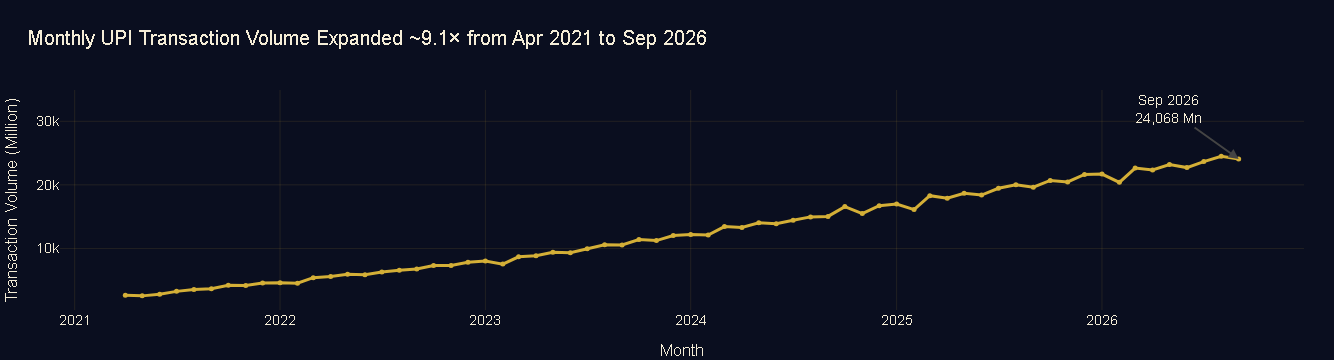

In [2]:
# ============================================================
# CHART 1 — Monthly UPI Transaction Volume Trend
# Shows the long-term expansion in monthly transaction activity
# ============================================================

# Calculate the overall expansion from the first month to the latest month
first_volume = df["volume_mn"].iloc[0]
latest_volume = df["volume_mn"].iloc[-1]

growth_multiple = latest_volume / first_volume


# Create the monthly volume trend chart
fig = go.Figure()


# Add monthly transaction volume
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["volume_mn"],
        mode="lines+markers",
        name="Transaction Volume",
        line=dict(
            width=3,
            color="#D4AF37"
        ),
        marker=dict(size=5),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            "Volume: %{y:,.0f} Mn"
            "<extra></extra>"
        )
    )
)


# Highlight the latest observation
fig.add_annotation(
    x=df["date"].iloc[-1],
    y=df["volume_mn"].iloc[-1],
    text=(
        f"Sep 2026<br>"
        f"{latest_volume:,.0f} Mn"
    ),
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-50
)


# Add clear axis labels
fig.update_xaxes(
    title_text="Month"
)

fig.update_yaxes(
    title_text="Transaction Volume (Million)"
)


# Create an insight-led title
title_chart_1 = (
    f"Monthly UPI Transaction Volume Expanded "
    f"~{growth_multiple:.1f}× from Apr 2021 to Sep 2026"
)


# Finalise and export Chart 1
finish(
    fig,
    "01_monthly_volume_trend",
    title_chart_1
)

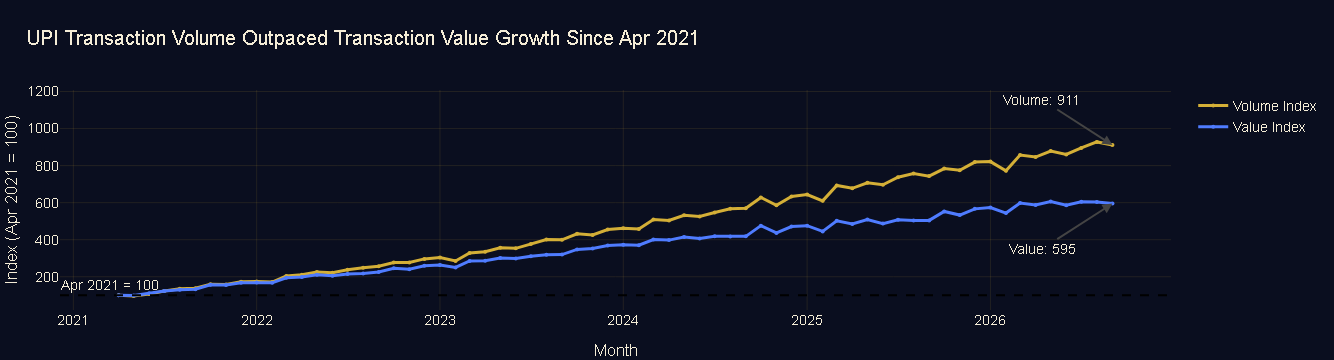

In [3]:
# ============================================================
# CHART 2 — Indexed UPI Volume vs Transaction Value
# Both series start at 100 in April 2021 for fair comparison
# ============================================================

# Set April 2021 as the base period
volume_base = df["volume_mn"].iloc[0]
value_base = df["value_cr"].iloc[0]


# Calculate indexed values
df["volume_index"] = (
    df["volume_mn"] / volume_base
) * 100

df["value_index"] = (
    df["value_cr"] / value_base
) * 100


# Calculate latest index values
latest_volume_index = df["volume_index"].iloc[-1]
latest_value_index = df["value_index"].iloc[-1]


# Create the indexed comparison chart
fig = go.Figure()


# Add transaction volume index
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["volume_index"],
        mode="lines+markers",
        name="Volume Index",
        line=dict(
            width=3,
            color="#D4AF37"
        ),
        marker=dict(size=4),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            "Volume Index: %{y:.1f}"
            "<extra></extra>"
        )
    )
)


# Add transaction value index
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["value_index"],
        mode="lines+markers",
        name="Value Index",
        line=dict(
            width=3,
            color="#4F7CFF"
        ),
        marker=dict(size=4),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            "Value Index: %{y:.1f}"
            "<extra></extra>"
        )
    )
)


# Add the base-period reference line
fig.add_hline(
    y=100,
    line_dash="dash",
    annotation_text="Apr 2021 = 100",
    annotation_position="top left"
)


# Annotate the latest volume index
fig.add_annotation(
    x=df["date"].iloc[-1],
    y=latest_volume_index,
    text=f"Volume: {latest_volume_index:.0f}",
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-45
)


# Annotate the latest value index
fig.add_annotation(
    x=df["date"].iloc[-1],
    y=latest_value_index,
    text=f"Value: {latest_value_index:.0f}",
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=45
)


# Add clear axis labels
fig.update_xaxes(
    title_text="Month"
)

fig.update_yaxes(
    title_text="Index (Apr 2021 = 100)"
)


# Create an insight-led title
title_chart_2 = (
    "UPI Transaction Volume Outpaced Transaction Value Growth "
    "Since Apr 2021"
)


# Finalise and export Chart 2
finish(
    fig,
    "02_indexed_volume_value",
    title_chart_2
)

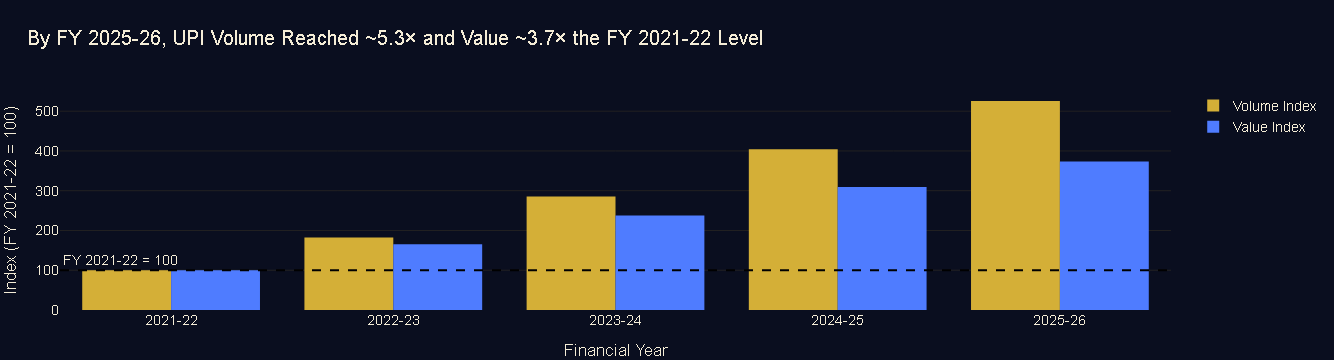

In [4]:
# ============================================================
# CHART 3 — Financial-Year Volume vs Value Growth
# Complete financial years are indexed to FY 2021-22 = 100
# FY 2026-27 is excluded because only 6 months are available
# ============================================================

# Aggregate monthly data to financial-year level
fy = (
    df.groupby("financial_year")
    .agg(
        months_available=("date", "count"),
        volume_mn=("volume_mn", "sum"),
        value_cr=("value_cr", "sum")
    )
    .reset_index()
)


# Keep only complete financial years
fy_complete = fy[
    fy["months_available"] == 12
].copy()


# Set FY 2021-22 as the base year
base_volume = fy_complete.loc[
    fy_complete["financial_year"] == "2021-22",
    "volume_mn"
].iloc[0]

base_value = fy_complete.loc[
    fy_complete["financial_year"] == "2021-22",
    "value_cr"
].iloc[0]


# Calculate indexed volume and value
fy_complete["volume_index"] = (
    fy_complete["volume_mn"] / base_volume
) * 100

fy_complete["value_index"] = (
    fy_complete["value_cr"] / base_value
) * 100


# Get the latest complete financial year
latest_fy = fy_complete.iloc[-1]

latest_fy_volume_index = latest_fy["volume_index"]
latest_fy_value_index = latest_fy["value_index"]


# Calculate relative expansion from the base year
volume_multiple = latest_fy_volume_index / 100
value_multiple = latest_fy_value_index / 100


# Create the grouped bar chart
fig = go.Figure()


# Add volume index
fig.add_trace(
    go.Bar(
        x=fy_complete["financial_year"],
        y=fy_complete["volume_index"],
        name="Volume Index",
        marker_color="#D4AF37",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Volume Index: %{y:.1f}"
            "<extra></extra>"
        )
    )
)


# Add value index
fig.add_trace(
    go.Bar(
        x=fy_complete["financial_year"],
        y=fy_complete["value_index"],
        name="Value Index",
        marker_color="#4F7CFF",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Value Index: %{y:.1f}"
            "<extra></extra>"
        )
    )
)


# Add the base-year reference level
fig.add_hline(
    y=100,
    line_dash="dash",
    annotation_text="FY 2021-22 = 100",
    annotation_position="top left"
)


# Add clear axis labels
fig.update_xaxes(
    title_text="Financial Year"
)

fig.update_yaxes(
    title_text="Index (FY 2021-22 = 100)"
)


# Display bars side by side
fig.update_layout(
    barmode="group"
)


# Create an insight-led title
title_chart_3 = (
    f"By FY 2025-26, UPI Volume Reached ~{volume_multiple:.1f}× "
    f"and Value ~{value_multiple:.1f}× the FY 2021-22 Level"
)


# Finalise and export Chart 3
finish(
    fig,
    "03_fy_volume_value_index",
    title_chart_3
)

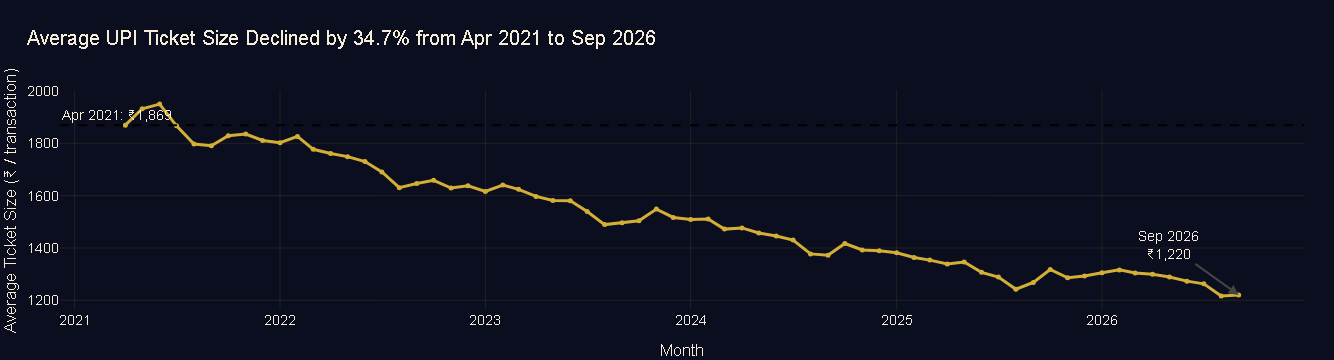

In [5]:
# ============================================================
# CHART 4 — Average UPI Ticket Size Trend
# Shows how the average rupee value per UPI transaction changed
# over the study period
# ============================================================

# Calculate the first and latest average ticket size
first_ticket = df["avg_ticket_size"].iloc[0]
latest_ticket = df["avg_ticket_size"].iloc[-1]

ticket_change_pct = (
    (latest_ticket - first_ticket) / first_ticket
) * 100


# Create the average ticket size trend chart
fig = go.Figure()


# Add average ticket size
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["avg_ticket_size"],
        mode="lines+markers",
        name="Average Ticket Size",
        line=dict(
            width=3,
            color="#D4AF37"
        ),
        marker=dict(size=5),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            "Average Ticket: ₹%{y:,.0f}"
            "<extra></extra>"
        )
    )
)


# Add the latest observation annotation
fig.add_annotation(
    x=df["date"].iloc[-1],
    y=df["avg_ticket_size"].iloc[-1],
    text=(
        f"Sep 2026<br>"
        f"₹{latest_ticket:,.0f}"
    ),
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-50
)


# Add a reference line using the first month's value
fig.add_hline(
    y=first_ticket,
    line_dash="dash",
    annotation_text=f"Apr 2021: ₹{first_ticket:,.0f}",
    annotation_position="top left"
)


# Add clear axis labels
fig.update_xaxes(
    title_text="Month"
)

fig.update_yaxes(
    title_text="Average Ticket Size (₹ / transaction)"
)


# Create an insight-led title
direction = "Declined" if ticket_change_pct < 0 else "Increased"

title_chart_4 = (
    f"Average UPI Ticket Size {direction} "
    f"by {abs(ticket_change_pct):.1f}% from Apr 2021 to Sep 2026"
)


# Finalise and export Chart 4
finish(
    fig,
    "04_average_ticket_size",
    title_chart_4
)

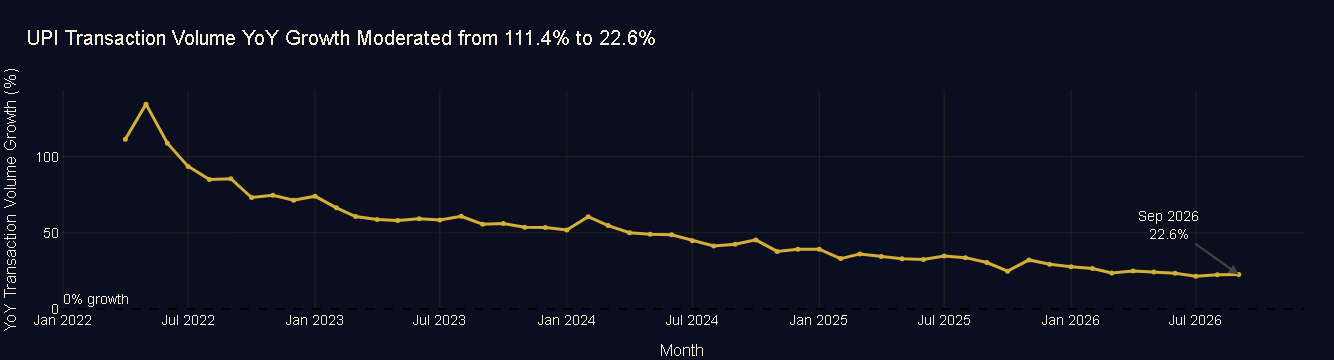

In [6]:
# ============================================================
# CHART 5 — Year-over-Year UPI Transaction Volume Growth
# Shows how the annual growth rate changed over time
# ============================================================

# Keep only months where YoY growth is available
yoy_df = df.dropna(
    subset=["yoy_growth_pct"]
).copy()


# Get the first and latest available YoY growth values
first_yoy = yoy_df["yoy_growth_pct"].iloc[0]
latest_yoy = yoy_df["yoy_growth_pct"].iloc[-1]

yoy_change = latest_yoy - first_yoy


# Create the YoY growth chart
fig = go.Figure()


# Add YoY growth line
fig.add_trace(
    go.Scatter(
        x=yoy_df["date"],
        y=yoy_df["yoy_growth_pct"],
        mode="lines+markers",
        name="YoY Growth",
        line=dict(
            width=3,
            color="#D4AF37"
        ),
        marker=dict(size=5),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            "YoY Growth: %{y:.1f}%"
            "<extra></extra>"
        )
    )
)


# Add the zero-growth reference line
fig.add_hline(
    y=0,
    line_dash="dash",
    annotation_text="0% growth",
    annotation_position="top left"
)


# Highlight the latest YoY growth
fig.add_annotation(
    x=yoy_df["date"].iloc[-1],
    y=latest_yoy,
    text=(
        f"Sep 2026<br>"
        f"{latest_yoy:.1f}%"
    ),
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-50
)


# Add clear axis labels
fig.update_xaxes(
    title_text="Month"
)

fig.update_yaxes(
    title_text="YoY Transaction Volume Growth (%)"
)


# Create an insight-led title
if yoy_change < 0:
    title_chart_5 = (
        f"UPI Transaction Volume YoY Growth Moderated "
        f"from {first_yoy:.1f}% to {latest_yoy:.1f}%"
    )
else:
    title_chart_5 = (
        f"UPI Transaction Volume YoY Growth Increased "
        f"from {first_yoy:.1f}% to {latest_yoy:.1f}%"
    )


# Finalise and export Chart 5
finish(
    fig,
    "05_yoy_growth_trend",
    title_chart_5
)

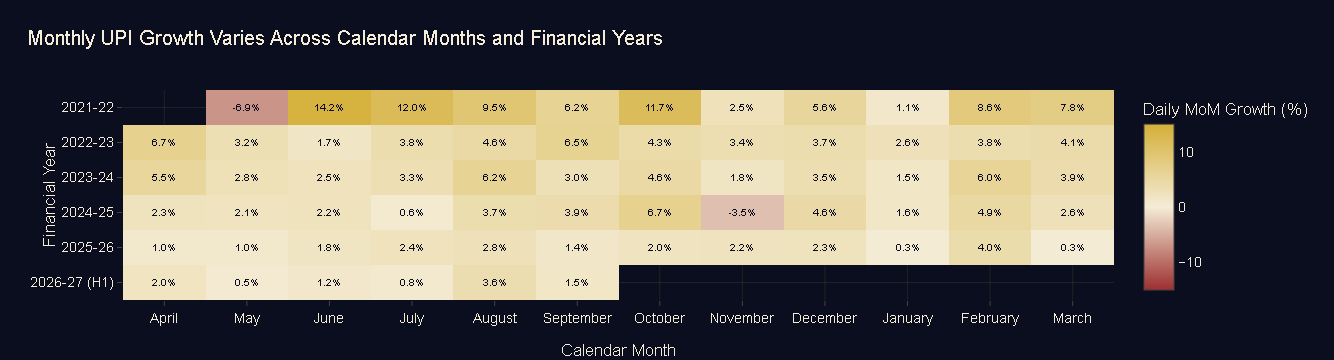

In [9]:
# ============================================================
# CHART 6 — MoM Growth Heatmap
# Shows daily-adjusted monthly growth by financial year/month
# ============================================================

# Define the financial-year calendar month order
month_order = [
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March"
]


# Create a working copy for the heatmap
heatmap_df = df.copy()


# Create calendar month names
heatmap_df["calendar_month"] = (
    heatmap_df["date"].dt.strftime("%B")
)


# Convert calendar months into financial-year order
heatmap_df["calendar_month"] = pd.Categorical(
    heatmap_df["calendar_month"],
    categories=month_order,
    ordered=True
)


# Mark the incomplete 2026-27 financial year as H1
heatmap_df["fy_label"] = (
    heatmap_df["financial_year"]
)

heatmap_df.loc[
    heatmap_df["financial_year"] == "2026-27",
    "fy_label"
] = "2026-27 (H1)"


# Sort the data
heatmap_df = heatmap_df.sort_values(
    ["financial_year", "calendar_month"]
)


# Create the heatmap matrix
heatmap_data = heatmap_df.pivot(
    index="fy_label",
    columns="calendar_month",
    values="daily_mom_pct"
)


# Keep months in the intended order
heatmap_data = heatmap_data.reindex(
    columns=month_order
)


# Reverse rows so the earliest financial year appears at the top
heatmap_data = heatmap_data.iloc[::-1]


# Calculate a symmetric colour range around zero
max_abs_growth = np.nanmax(
    np.abs(heatmap_data.values)
)

colour_limit = np.ceil(max_abs_growth)


# Create the heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index,

        colorscale=[
            [0.0, "#9C2F2F"],
            [0.5, "#F4ECD6"],
            [1.0, "#D4AF37"]
        ],

        zmin=-colour_limit,
        zmax=colour_limit,
        zmid=0,

        colorbar=dict(
            title="Daily MoM Growth (%)"
        ),

        hovertemplate=(
            "<b>%{y}</b><br>"
            "%{x}<br>"
            "Daily MoM: %{z:.1f}%"
            "<extra></extra>"
        )
    )
)


# Add growth percentages inside the cells
for row_index, financial_year in enumerate(
    heatmap_data.index
):

    for col_index, month in enumerate(
        heatmap_data.columns
    ):

        value = heatmap_data.loc[
            financial_year,
            month
        ]

        if pd.notna(value):

            fig.add_annotation(
                x=month,
                y=financial_year,
                text=f"{value:.1f}%",
                showarrow=False,
                font=dict(
                    size=10,
                    color="#0A0E1F"
                )
            )


# Improve spacing so all financial-year labels are fully visible
fig.update_layout(
    margin=dict(
        l=120,
        r=40,
        t=90,
        b=60
    )
)

fig.update_yaxes(
    automargin=True
)

# Add clear axis labels
fig.update_xaxes(
    title_text="Calendar Month"
)

fig.update_yaxes(
    title_text="Financial Year"
)


# Create an insight-led but descriptive title
title_chart_6 = (
    "Monthly UPI Growth Varies Across Calendar Months "
    "and Financial Years"
)


# Finalise and export Chart 6
finish(
    fig,
    "06_mom_growth_heatmap",
    title_chart_6
)

Seasonality Index by Month:


,calendar_month,seasonality_index
0,April,82.1
1,May,82.7
2,June,85.9
3,July,89.5
4,August,94.2
5,September,98.1
6,October,103.8
7,November,105.1
8,December,109.3
9,January,110.9



Festive (Oct-Nov) average index: 104.5
Other months average index: 99.1
Festive vs other-month difference: +5.4 index points

Peak month: March (121.5)
Lowest month: April (82.1)


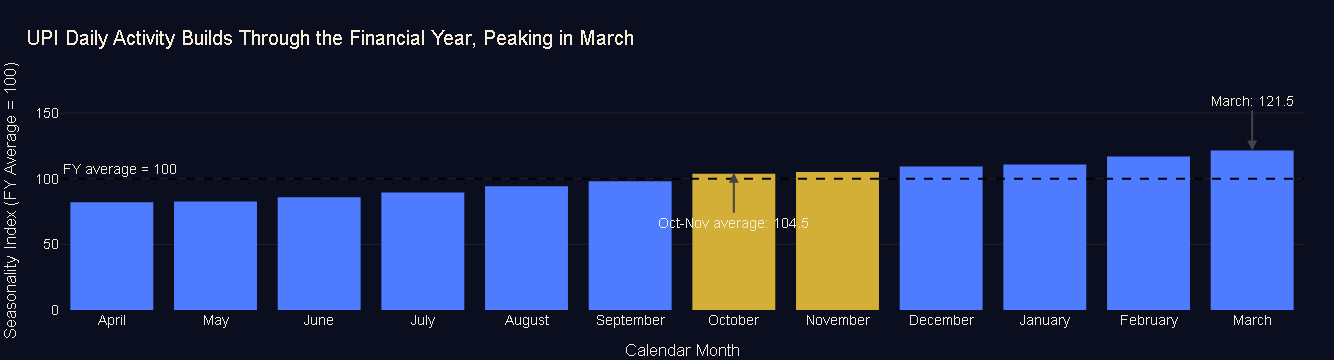

In [11]:
# ============================================================
# CHART 7 — UPI Seasonality Index
# Compares each calendar month with its financial-year average
# using daily transaction volume to remove month-length effects
# ============================================================

# Keep only complete financial years
seasonality_df = df[
    df["fy_months_available"] == 12
].copy()


# ============================================================
# Calculate the seasonality index
# 100 = average daily volume for that financial year
# ============================================================

fy_daily_avg = (
    seasonality_df
    .groupby("financial_year")["avg_daily_volume_mn"]
    .transform("mean")
)

seasonality_df["seasonality_index"] = (
    seasonality_df["avg_daily_volume_mn"]
    / fy_daily_avg
) * 100


# ============================================================
# Create calendar month names
# ============================================================

seasonality_df["calendar_month"] = (
    seasonality_df["date"].dt.strftime("%B")
)


# Define financial-year calendar order
month_order = [
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March"
]


# Apply the correct month order
seasonality_df["calendar_month"] = pd.Categorical(
    seasonality_df["calendar_month"],
    categories=month_order,
    ordered=True
)


# ============================================================
# Calculate average seasonality for each calendar month
# across complete financial years
# ============================================================

seasonality = (
    seasonality_df
    .groupby(
        "calendar_month",
        observed=False
    )["seasonality_index"]
    .mean()
    .reindex(month_order)
    .reset_index()
)


# ============================================================
# Identify festive months
# ============================================================

seasonality["is_festive"] = (
    seasonality["calendar_month"].isin(
        ["October", "November"]
    )
)


# ============================================================
# Calculate festive vs other-month averages
# ============================================================

festive_avg = seasonality.loc[
    seasonality["is_festive"],
    "seasonality_index"
].mean()

other_avg = seasonality.loc[
    ~seasonality["is_festive"],
    "seasonality_index"
].mean()

festive_difference = festive_avg - other_avg


# ============================================================
# Identify the highest and lowest seasonal months
# ============================================================

peak_row = seasonality.loc[
    seasonality["seasonality_index"].idxmax()
]

low_row = seasonality.loc[
    seasonality["seasonality_index"].idxmin()
]

peak_month = peak_row["calendar_month"]
peak_index = peak_row["seasonality_index"]

low_month = low_row["calendar_month"]
low_index = low_row["seasonality_index"]


# ============================================================
# Display the seasonality table
# ============================================================

print("Seasonality Index by Month:")

display(
    seasonality[
        [
            "calendar_month",
            "seasonality_index"
        ]
    ].round(1)
)


# ============================================================
# Display the festive comparison
# ============================================================

print(
    f"\nFestive (Oct-Nov) average index: "
    f"{festive_avg:.1f}"
)

print(
    f"Other months average index: "
    f"{other_avg:.1f}"
)

print(
    f"Festive vs other-month difference: "
    f"{festive_difference:+.1f} index points"
)

print(
    f"\nPeak month: {peak_month} "
    f"({peak_index:.1f})"
)

print(
    f"Lowest month: {low_month} "
    f"({low_index:.1f})"
)


# ============================================================
# Create bar colours
# Gold = festive months
# Blue = other months
# ============================================================

bar_colors = [
    "#D4AF37" if festive else "#4F7CFF"
    for festive in seasonality["is_festive"]
]


# ============================================================
# Create the seasonality chart
# ============================================================

fig = go.Figure()


fig.add_trace(
    go.Bar(
        x=seasonality["calendar_month"],
        y=seasonality["seasonality_index"],
        name="Seasonality Index",
        marker_color=bar_colors,

        hovertemplate=(
            "<b>%{x}</b><br>"
            "Seasonality Index: %{y:.1f}"
            "<extra></extra>"
        )
    )
)


# ============================================================
# Add the neutral FY-average reference line
# ============================================================

fig.add_hline(
    y=100,
    line_dash="dash",
    annotation_text="FY average = 100",
    annotation_position="top left"
)


# ============================================================
# Highlight the seasonal peak
# ============================================================

fig.add_annotation(
    x=peak_month,
    y=peak_index,
    text=(
        f"{peak_month}: {peak_index:.1f}"
    ),
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50
)


# ============================================================
# Highlight the October-November average
# ============================================================

fig.add_annotation(
    x="October",
    y=festive_avg,
    text=(
        f"Oct-Nov average: {festive_avg:.1f}"
    ),
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=50
)


# ============================================================
# Add clear axis labels
# ============================================================

fig.update_xaxes(
    title_text="Calendar Month"
)

fig.update_yaxes(
    title_text="Seasonality Index (FY Average = 100)"
)


# ============================================================
# Create a data-driven title
# ============================================================

title_chart_7 = (
    f"UPI Daily Activity Builds Through the Financial Year, "
    f"Peaking in {peak_month}"
)


# ============================================================
# Finalise and export Chart 7
# ============================================================

finish(
    fig,
    "07_seasonality_index",
    title_chart_7
)

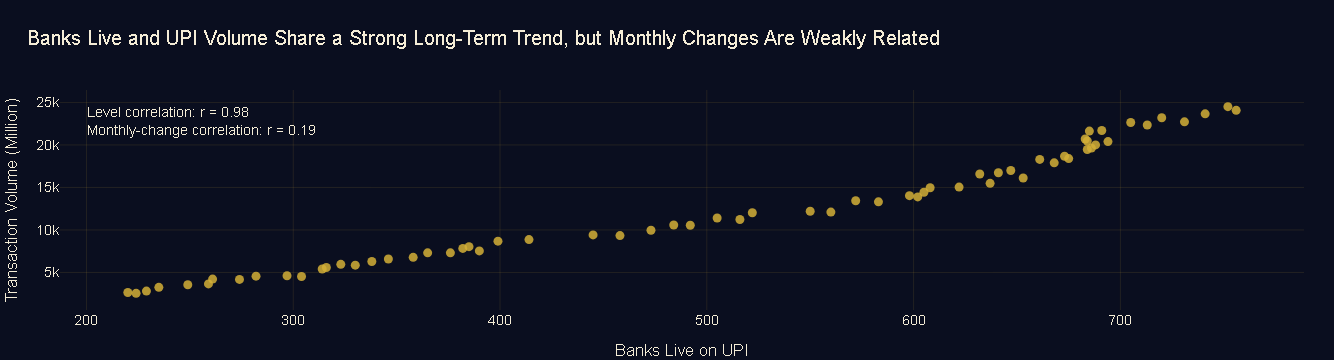

Level correlation: 0.98
Monthly-change correlation: 0.19


In [14]:
# ============================================================
# CHART 8 — Banks Live vs Transaction Volume
# Compare both level correlation and month-to-month movement
# to avoid relying only on a common long-term trend
# ============================================================

# Calculate correlation in the original levels
level_correlation = df[
    ["banks_live", "volume_mn"]
].corr().loc[
    "banks_live",
    "volume_mn"
]


# Calculate month-to-month percentage changes
change_df = df[
    ["date", "banks_live", "volume_mn"]
].copy()

change_df["banks_change_pct"] = (
    change_df["banks_live"].pct_change() * 100
)

change_df["volume_change_pct"] = (
    change_df["volume_mn"].pct_change() * 100
)


# Calculate correlation between monthly changes
change_correlation = change_df[
    ["banks_change_pct", "volume_change_pct"]
].corr().loc[
    "banks_change_pct",
    "volume_change_pct"
]


# Create the scatter plot
fig = go.Figure()


fig.add_trace(
    go.Scatter(
        x=df["banks_live"],
        y=df["volume_mn"],
        mode="markers",
        name="Monthly observations",

        marker=dict(
            size=9,
            color="#D4AF37",
            opacity=0.85
        ),

        customdata=np.column_stack([
            df["date"].dt.strftime("%b %Y"),
            df["financial_year"]
        ]),

        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Financial Year: %{customdata[1]}<br>"
            "Banks Live: %{x:,.0f}<br>"
            "Volume: %{y:,.0f} Mn"
            "<extra></extra>"
        )
    )
)


# Add correlation information
fig.add_annotation(
    x=0.02,
    y=0.95,
    xref="paper",
    yref="paper",
    text=(
        f"Level correlation: r = {level_correlation:.2f}"
        f"<br>"
        f"Monthly-change correlation: r = {change_correlation:.2f}"
    ),
    showarrow=False,
    align="left"
)


# Add clear axis labels
fig.update_xaxes(
    title_text="Banks Live on UPI"
)

fig.update_yaxes(
    title_text="Transaction Volume (Million)"
)


# Use neutral, non-causal wording
title_chart_8 = (
    "Banks Live and UPI Volume Share a Strong Long-Term Trend, "
    "but Monthly Changes Are Weakly Related"
)


# Finalise and export Chart 8
finish(
    fig,
    "08_banks_vs_volume",
    title_chart_8
)


# Print the two correlation measures for interpretation
print(
    f"Level correlation: {level_correlation:.2f}"
)

print(
    f"Monthly-change correlation: {change_correlation:.2f}"
)

In [16]:
# ============================================================
# STEP 10 — Daily-Metric QA Table
# Verify that monthly totals correctly reconcile to daily averages
# ============================================================

# Create a validation table using selected representative months
qa = df[
    [
        "date",
        "month",
        "days_in_month",
        "volume_mn",
        "avg_daily_volume_mn",
        "value_cr",
        "avg_daily_value_cr"
    ]
].copy()


# Recalculate daily averages independently
qa["recalculated_daily_volume_mn"] = (
    qa["volume_mn"] / qa["days_in_month"]
)

qa["recalculated_daily_value_cr"] = (
    qa["value_cr"] / qa["days_in_month"]
)


# Calculate reconciliation differences
qa["volume_difference"] = (
    qa["avg_daily_volume_mn"]
    - qa["recalculated_daily_volume_mn"]
)

qa["value_difference"] = (
    qa["avg_daily_value_cr"]
    - qa["recalculated_daily_value_cr"]
)


# Verify that the stored daily averages match the recalculated values
assert np.allclose(
    qa["avg_daily_volume_mn"],
    qa["recalculated_daily_volume_mn"],
    rtol=1e-10,
    atol=1e-10
)

assert np.allclose(
    qa["avg_daily_value_cr"],
    qa["recalculated_daily_value_cr"],
    rtol=1e-10,
    atol=1e-10
)


# Display representative rows from the beginning, middle, and latest period
sample_indices = [
    0,
    len(qa) // 2,
    len(qa) - 1
]

# Display representative QA rows with numeric values rounded
qa_display = qa.loc[
    sample_indices,
    [
        "date",
        "days_in_month",
        "volume_mn",
        "avg_daily_volume_mn",
        "value_cr",
        "avg_daily_value_cr",
        "volume_difference",
        "value_difference"
    ]
].copy()

numeric_columns = qa_display.select_dtypes(
    include="number"
).columns

qa_display[numeric_columns] = (
    qa_display[numeric_columns].round(4)
)

display(qa_display)

print(
    "\nDaily-average reconciliation: PASS"
)

,date,days_in_month,volume_mn,avg_daily_volume_mn,value_cr,avg_daily_value_cr,volume_difference,value_difference
0,2021-04-01,30,2641.06,88.0353,493663.68,16455.4560,0.0,0.0
33,2024-01-01,31,12203.02,393.6458,1841083.97,59389.8055,0.0,0.0
65,2026-09-01,30,24068.38,802.2793,2937396.67,97913.2223,0.0,0.0



Daily-average reconciliation: PASS


In [17]:
# ============================================================
# STEP 11 — Key Business Insights
# Generate verified, data-driven findings from the EDA
# ============================================================


# ============================================================
# 1. Long-term transaction volume expansion
# ============================================================

first_volume = df["volume_mn"].iloc[0]
latest_volume = df["volume_mn"].iloc[-1]

volume_multiple = (
    latest_volume / first_volume
)


# ============================================================
# 2. Long-term transaction value expansion
# ============================================================

first_value = df["value_cr"].iloc[0]
latest_value = df["value_cr"].iloc[-1]

value_multiple = (
    latest_value / first_value
)


# ============================================================
# 3. Average ticket size change
# ============================================================

first_ticket = df["avg_ticket_size"].iloc[0]
latest_ticket = df["avg_ticket_size"].iloc[-1]

ticket_change_pct = (
    (latest_ticket - first_ticket)
    / first_ticket
) * 100


# ============================================================
# 4. Latest YoY growth
# ============================================================

latest_yoy = df["yoy_growth_pct"].dropna().iloc[-1]


# ============================================================
# 5. Strongest and weakest seasonality months
# ============================================================

peak_seasonality = seasonality.loc[
    seasonality["seasonality_index"].idxmax()
]

low_seasonality = seasonality.loc[
    seasonality["seasonality_index"].idxmin()
]


peak_month = peak_seasonality["calendar_month"]
peak_index = peak_seasonality["seasonality_index"]

low_month = low_seasonality["calendar_month"]
low_index = low_seasonality["seasonality_index"]


# ============================================================
# 6. Festive-period comparison
# ============================================================

festive_avg = seasonality.loc[
    seasonality["is_festive"],
    "seasonality_index"
].mean()

other_avg = seasonality.loc[
    ~seasonality["is_festive"],
    "seasonality_index"
].mean()

festive_difference = (
    festive_avg - other_avg
)


# ============================================================
# 7. Banks and transaction volume relationship
# ============================================================

level_correlation = df[
    ["banks_live", "volume_mn"]
].corr().loc[
    "banks_live",
    "volume_mn"
]


change_df = df[
    ["banks_live", "volume_mn"]
].copy()

change_df["banks_change_pct"] = (
    change_df["banks_live"].pct_change() * 100
)

change_df["volume_change_pct"] = (
    change_df["volume_mn"].pct_change() * 100
)

change_correlation = change_df[
    ["banks_change_pct", "volume_change_pct"]
].corr().loc[
    "banks_change_pct",
    "volume_change_pct"
]


# ============================================================
# 8. Print the verified key findings
# ============================================================

print("=" * 70)
print("KEY BUSINESS INSIGHTS")
print("=" * 70)


print(
    f"\n1. Monthly transaction volume expanded "
    f"~{volume_multiple:.1f}× "
    f"from Apr 2021 to Sep 2026."
)


print(
    f"\n2. Monthly transaction value expanded "
    f"~{value_multiple:.1f}× "
    f"from Apr 2021 to Sep 2026."
)


print(
    f"\n3. Average ticket size changed from "
    f"₹{first_ticket:,.0f} to ₹{latest_ticket:,.0f}, "
    f"a {abs(ticket_change_pct):.1f}% "
    f"{'decline' if ticket_change_pct < 0 else 'increase'}."
)


print(
    f"\n4. Latest available YoY transaction-volume growth "
    f"(Sep 2026): {latest_yoy:.1f}%."
)


print(
    f"\n5. Average daily UPI activity is highest in "
    f"{peak_month} "
    f"(seasonality index {peak_index:.1f}) "
    f"and lowest in {low_month} "
    f"({low_index:.1f})."
)


print(
    f"\n6. October-November average seasonality index is "
    f"{festive_avg:.1f}, compared with "
    f"{other_avg:.1f} for other months "
    f"({festive_difference:+.1f} index points)."
)


print(
    f"\n7. Banks live and transaction volume have a "
    f"level correlation of {level_correlation:.2f}, "
    f"while their monthly-change correlation is "
    f"{change_correlation:.2f}."
)


# ============================================================
# 9. Create README-ready insight text
# ============================================================

insights = f"""
# Key Findings

- Monthly UPI transaction volume expanded approximately {volume_multiple:.1f}× from April 2021 to September 2026.
- Monthly UPI transaction value expanded approximately {value_multiple:.1f}× over the same period.
- Average ticket size changed from ₹{first_ticket:,.0f} to ₹{latest_ticket:,.0f}, representing a {abs(ticket_change_pct):.1f}% {'decline' if ticket_change_pct < 0 else 'increase'}.
- The latest available YoY transaction-volume growth in September 2026 was {latest_yoy:.1f}%.
- Average daily UPI activity was highest in {peak_month} at a seasonality index of {peak_index:.1f}, and lowest in {low_month} at {low_index:.1f}.
- October-November averaged {festive_avg:.1f} on the seasonality index versus {other_avg:.1f} for other months.
- Banks live and transaction volume show a level correlation of {level_correlation:.2f}; the monthly-change correlation is {change_correlation:.2f}.
"""


# ============================================================
# 10. Save the findings for later README/report use
# ============================================================

Path("../docs").mkdir(exist_ok=True)

Path("../docs/key_findings.md").write_text(
    insights.strip(),
    encoding="utf-8"
)

print(
    "\nKey findings saved to ../docs/key_findings.md"
)

KEY BUSINESS INSIGHTS

1. Monthly transaction volume expanded ~9.1× from Apr 2021 to Sep 2026.

2. Monthly transaction value expanded ~6.0× from Apr 2021 to Sep 2026.

3. Average ticket size changed from ₹1,869 to ₹1,220, a 34.7% decline.

4. Latest available YoY transaction-volume growth (Sep 2026): 22.6%.

5. Average daily UPI activity is highest in March (seasonality index 121.5) and lowest in April (82.1).

6. October-November average seasonality index is 104.5, compared with 99.1 for other months (+5.4 index points).

7. Banks live and transaction volume have a level correlation of 0.98, while their monthly-change correlation is 0.19.

Key findings saved to ../docs/key_findings.md
